# Version B — All-orthologs comparison (RBH), Kushige2013 vs. Ito2009

See `PROJECT_BRIEF_rhythmic_gene_comparison.md` §7 and `hurdles.md` (2026-07-27 entry).

Version A (rhythmic-restricted, name-matched) is demonstrated non-viable: the name-matched
overlap among either paper's own headline rhythmic set collapses to n=1-2 regardless of
where the amplitude threshold is drawn (swept 50th-90th percentile). This notebook builds
the unbiased alternative: reciprocal-best-BLAST-hit (RBH) orthologs across the FULL
proteomes, independent of rhythmicity, removing H1 (selection bias) entirely and H2
(name-matching's low recall on largely-unnamed genomes) mostly.

Genome sources: `data/raw/genomes/SOURCES.txt`. Both are each paper's own reference
genome (locus-tag schemes match exactly via GFF `old_locus_tag`), fetched via the NCBI
Datasets API.

## 1. Build locus_tag <-> protein_id maps from each genome's GFF3

The protein FASTA headers use RefSeq `WP_...` protein accessions, not the classic locus
tags (`Synpcc7942_XXXX`, `all/alr/asl/asr####`) that Ito2009 and Kushige2013 use. Each
GFF's `gene` feature carries `old_locus_tag` (the classic tag) and shares its `ID` with
the child `CDS` feature, which carries `protein_id` -- join on that shared gene ID.

In [1]:
from pathlib import Path
import pandas as pd

def find_project_root(marker=".git"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}' above {p})")


repo_root = find_project_root()
genomes_dir = repo_root / "data" / "raw" / "genomes"
interim_dir = repo_root / "data" / "interim"
interim_dir.mkdir(parents=True, exist_ok=True)


def parse_attrs(attr_str):
    d = {}
    for kv in attr_str.strip().split(";"):
        if "=" in kv:
            k, v = kv.split("=", 1)
            d[k] = v
    return d


def build_locus_protein_map(gff_path):
    gene_id_to_old_locus = {}
    cds_rows = []
    with open(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 9:
                continue
            feature_type = fields[2]
            attrs = parse_attrs(fields[8])
            if feature_type == "gene":
                gid = attrs.get("ID")
                old_locus = attrs.get("old_locus_tag")
                if gid and old_locus:
                    gene_id_to_old_locus[gid] = old_locus
            elif feature_type == "CDS":
                parent = attrs.get("Parent")
                protein_id = attrs.get("protein_id")
                if parent and protein_id:
                    cds_rows.append((parent, protein_id))
    rows = [
        {"old_locus_tag": gene_id_to_old_locus[parent], "protein_id": protein_id}
        for parent, protein_id in cds_rows
        if parent in gene_id_to_old_locus
    ]
    return pd.DataFrame(rows).drop_duplicates()


ito_map = build_locus_protein_map(genomes_dir / "synechococcus_7942_GCF_000012525.1" / "genomic.gff")
kushige_map = build_locus_protein_map(genomes_dir / "anabaena_pcc7120_GCF_000009705.1" / "genomic.gff")

print(f"7942 locus<->protein map: {len(ito_map)} rows")
print(f"  duplicated old_locus_tag (ambiguous mapping)?", ito_map["old_locus_tag"].duplicated().sum())
print(f"Anabaena locus<->protein map: {len(kushige_map)} rows")
print(f"  duplicated old_locus_tag (ambiguous mapping)?", kushige_map["old_locus_tag"].duplicated().sum())

ito_map.to_csv(interim_dir / "synechococcus_locus_protein_map.csv", index=False)
kushige_map.to_csv(interim_dir / "anabaena_locus_protein_map.csv", index=False)
ito_map.head()

7942 locus<->protein map: 2617 rows
  duplicated old_locus_tag (ambiguous mapping)? 0
Anabaena locus<->protein map: 5398 rows
  duplicated old_locus_tag (ambiguous mapping)? 0


,old_locus_tag,protein_id
0,Synpcc7942_0001,WP_070105208.1
1,Synpcc7942_0002,WP_199290672.1
2,Synpcc7942_0003,WP_011243804.1
3,Synpcc7942_0004,WP_011243803.1
4,Synpcc7942_0005,WP_011377397.1


## 2. Reciprocal best BLAST hit (RBH)

Build a BLAST DB for each proteome, run `blastp` in both directions (7942 queries against
the Anabaena DB, and vice versa), keep each query's single best hit by bitscore, and take
the intersection where A's best hit is B AND B's best hit is A.

In [2]:
import subprocess

blast_dir = interim_dir / "blast"
blast_dir.mkdir(exist_ok=True)

ito_faa = genomes_dir / "synechococcus_7942_GCF_000012525.1" / "protein.faa"
kushige_faa = genomes_dir / "anabaena_pcc7120_GCF_000009705.1" / "protein.faa"

ito_db = blast_dir / "synechococcus_db"
kushige_db = blast_dir / "anabaena_db"

for faa, db in [(ito_faa, ito_db), (kushige_faa, kushige_db)]:
    subprocess.run(
        ["makeblastdb", "-in", str(faa), "-dbtype", "prot", "-out", str(db)],
        check=True, capture_output=True,
    )
print("BLAST DBs built.")

fmt = "6 qseqid sseqid pident length evalue bitscore"

def run_blastp(query_faa, db, out_path):
    # capture_output=True: blastp's "-max_target_seqs 1" cosmetic warning ("Examining 5
    # or more matches is recommended") is expected and harmless here -- we don't rely on
    # max_target_seqs for correctness, we explicitly re-sort by bitscore below.
    subprocess.run(
        [
            "blastp", "-query", str(query_faa), "-db", str(db),
            "-outfmt", fmt, "-max_target_seqs", "1", "-evalue", "1e-5",
            "-num_threads", "4", "-out", str(out_path),
        ],
        check=True, capture_output=True,
    )

fwd_out = blast_dir / "7942_vs_anabaena.tsv"
rev_out = blast_dir / "anabaena_vs_7942.tsv"

run_blastp(ito_faa, kushige_db, fwd_out)
print("Forward BLAST (7942 -> Anabaena) done.")
run_blastp(kushige_faa, ito_db, rev_out)
print("Reverse BLAST (Anabaena -> 7942) done.")


BLAST DBs built.


Forward BLAST (7942 -> Anabaena) done.


Reverse BLAST (Anabaena -> 7942) done.


In [3]:
cols = ["qseqid", "sseqid", "pident", "length", "evalue", "bitscore"]
fwd = pd.read_csv(fwd_out, sep="\t", names=cols)
rev = pd.read_csv(rev_out, sep="\t", names=cols)

# -max_target_seqs 1 doesn't strictly guarantee the single best hit (it's a DB-traversal
# cap, not a sort), so explicitly take the max-bitscore row per query to be sure.
fwd_best = fwd.sort_values("bitscore", ascending=False).drop_duplicates("qseqid").set_index("qseqid")["sseqid"]
rev_best = rev.sort_values("bitscore", ascending=False).drop_duplicates("qseqid").set_index("qseqid")["sseqid"]

print(f"7942 proteins with a hit in Anabaena: {len(fwd_best)} / {ito_map['protein_id'].nunique()}")
print(f"Anabaena proteins with a hit in 7942: {len(rev_best)} / {kushige_map['protein_id'].nunique()}")

rbh_pairs = [
    (q7942, q_anabaena)
    for q7942, q_anabaena in fwd_best.items()
    if rev_best.get(q_anabaena) == q7942
]
print(f"\nReciprocal best hits: {len(rbh_pairs)}")

rbh_df = pd.DataFrame(rbh_pairs, columns=["protein_id_7942", "protein_id_anabaena"])
rbh_df = rbh_df.merge(ito_map.rename(columns={"protein_id": "protein_id_7942", "old_locus_tag": "locus_tag_7942"}), on="protein_id_7942")
rbh_df = rbh_df.merge(kushige_map.rename(columns={"protein_id": "protein_id_anabaena", "old_locus_tag": "locus_tag_anabaena"}), on="protein_id_anabaena")
rbh_df["ortholog_method"] = "RBH"
rbh_df["rbh_confirmed"] = True

processed_dir = repo_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
rbh_df.to_csv(processed_dir / "rbh_orthologs.csv", index=False)
print(f"\nWrote {len(rbh_df)} RBH ortholog pairs to data/processed/rbh_orthologs.csv")
rbh_df.head()


7942 proteins with a hit in Anabaena: 2117 / 2613
Anabaena proteins with a hit in 7942: 3158 / 5381

Reciprocal best hits: 1904

Wrote 1846 RBH ortholog pairs to data/processed/rbh_orthologs.csv


,protein_id_7942,protein_id_anabaena,locus_tag_7942,locus_tag_anabaena,ortholog_method,rbh_confirmed
0,WP_011377778.1,WP_010998481.1,Synpcc7942_0890,alr4344,RBH,True
1,WP_011244265.1,WP_010998502.1,Synpcc7942_2137,all4365,RBH,True
2,WP_011378064.1,WP_044521002.1,Synpcc7942_1522,alr1594,RBH,True
3,WP_011378007.1,WP_010994484.1,Synpcc7942_1372,alr0308,RBH,True
4,WP_011243131.1,WP_010997950.1,Synpcc7942_0711,alr3809,RBH,True


## 3. Join RBH pairs with full per-gene tables — no rhythmicity filter

Every gene gets a peak time and amplitude here, whether or not it was ever called
"rhythmic" by either paper: Ito2009's cosinor fit and Kushige2013's phase-folded argmax
(same method used earlier for the 16-gene deep dive) both produce a value for every gene,
rhythmic or not. Amplitude is carried through as a continuous column rather than used to
gate membership -- that's what makes this Version B and not just a bigger Version A.

In [4]:
repo_data = repo_root / "Ito2009" / "Ito2009_sd1.xls"
kushige_data = repo_root / "Kushige2013" / "Kushige2013_so2.xlsx"

# --- Ito2009: full 2515-gene table already has per-gene peak time / P / amplitude ---
ito_full = pd.read_excel(repo_data, sheet_name="Table S1", header=5)
ito_full = ito_full.rename(columns={
    "7942ID": "locus_tag_7942", "Gene Name": "gene_symbol_7942", "Annotation": "annotation_7942",
    "Peak time*": "peak_time_h_7942", "Correlation p-value*": "corr_p_7942",
    "Amplitude*": "amplitude_cv_7942", "Cycling property**": "rhythmic_tier_7942",
})[["locus_tag_7942", "gene_symbol_7942", "annotation_7942", "peak_time_h_7942",
    "corr_p_7942", "amplitude_cv_7942", "rhythmic_tier_7942"]]
# Peak time is "-" (a string placeholder) for genes with no well-defined phase -- coerce
# to numeric so those become NaN rather than poisoning the column's dtype to object.
for col in ["peak_time_h_7942", "corr_p_7942", "amplitude_cv_7942"]:
    ito_full[col] = pd.to_numeric(ito_full[col], errors="coerce")

# --- Kushige2013: compute CV / P / peak time for ALL 5336 genes (not just the 78) ---
kushige_raw = pd.read_excel(kushige_data, sheet_name="Sheet1", header=5)
ll_timepoints = [4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]
phases = sorted({t % 24 for t in ll_timepoints})
nplus_cols = [f"N+_1st_LL{t}" for t in ll_timepoints] + [f"N+_2nd_LL{t}" for t in ll_timepoints]
vals = kushige_raw[nplus_cols].astype(float)
kushige_raw["amplitude_cv_anabaena"] = vals.std(axis=1, ddof=1) / vals.mean(axis=1)

# H11 fix (hurdles.md, 2026-07-30): row 5's header "Ri value (t-test: p-value)" is a
# MERGED cell spanning columns 6-7 -- col 6 is the heterocyst-enrichment ratio, col 7
# (pandas' "Unnamed: 7") is that ratio's t-test p-value. It is NOT a rhythmicity
# p-value, though it was previously stored under that name. Renamed so the column can
# no longer assert a meaning it doesn't have.
kushige_raw["ri_ttest_p_anabaena"] = pd.to_numeric(
    kushige_raw["Unnamed: 7"].astype(str).str.strip("()"), errors="coerce"
)

# Real corr_p_anabaena: Data Set S1 (this spreadsheet) has NO rhythmicity p-value for
# any gene -- it is raw time series only. The only place a real one exists is Table S2
# in the SI PDF, and Table S2 lists ONLY the 78 genes Kushige calls cycling (tier a/b).
# So this is populated for those 78 and left null for everyone else -- not reconstructed
# from anything in the spreadsheet. `data/interim/kushige_rhythmic.csv` is Table S2
# parsed by src/01_parse_kushige.py.
table_s2 = pd.read_csv(interim_dir / "kushige_rhythmic.csv")[["gene_id", "corr_p"]].rename(
    columns={"gene_id": "ORF No.", "corr_p": "corr_p_anabaena"}
)
kushige_raw = kushige_raw.merge(table_s2, on="ORF No.", how="left")

def peak_time_nplus(row):
    by_phase = {p: [] for p in phases}
    for t in ll_timepoints:
        p = t % 24
        by_phase[p].append(row[f"N+_1st_LL{t}"])
        by_phase[p].append(row[f"N+_2nd_LL{t}"])
    avg = {p: sum(v) / len(v) for p, v in by_phase.items()}
    return max(avg, key=avg.get)

kushige_raw["peak_time_h_anabaena"] = kushige_raw.apply(peak_time_nplus, axis=1)
kushige_full = kushige_raw.rename(columns={
    "ORF No.": "locus_tag_anabaena", "Gene name": "gene_symbol_anabaena", "Annotation": "annotation_anabaena",
    "Cycling property (N+, n=2)*": "rhythmic_tier_anabaena",
})[["locus_tag_anabaena", "gene_symbol_anabaena", "annotation_anabaena", "peak_time_h_anabaena",
    "corr_p_anabaena", "ri_ttest_p_anabaena", "amplitude_cv_anabaena", "rhythmic_tier_anabaena"]]

print(f"Ito2009 full table: {len(ito_full)} genes ({ito_full['peak_time_h_7942'].isna().sum()} with no defined peak time)")
print(f"Kushige2013 full table (CV computed for all): {len(kushige_full)} genes")
print(f"  corr_p_anabaena populated (Table S2, tier a/b only): {kushige_full['corr_p_anabaena'].notna().sum()}")

# --- Join: RBH pairs x both full tables ---
rbh_df = pd.read_csv(processed_dir / "rbh_orthologs.csv")
all_orthologs = (
    rbh_df.merge(ito_full, on="locus_tag_7942", how="left")
    .merge(kushige_full, on="locus_tag_anabaena", how="left")
)

missing_7942 = all_orthologs["peak_time_h_7942"].isna().sum()
missing_anabaena = all_orthologs["peak_time_h_anabaena"].isna().sum()
print(f"\nRBH pairs: {len(all_orthologs)}")
print(f"  missing 7942-side peak time: {missing_7942} (no expression data, or no defined phase)")
print(f"  missing Anabaena-side peak time: {missing_anabaena}")

all_orthologs = all_orthologs.dropna(subset=["peak_time_h_7942", "peak_time_h_anabaena"]).copy()
print(f"  usable pairs (both sides have a defined peak time): {len(all_orthologs)}")

all_orthologs.to_csv(processed_dir / "all_orthologs_rbh.csv", index=False)
print(f"\nWrote {len(all_orthologs)} rows to data/processed/all_orthologs_rbh.csv")
all_orthologs[["locus_tag_7942", "gene_symbol_7942", "locus_tag_anabaena", "gene_symbol_anabaena",
               "peak_time_h_7942", "peak_time_h_anabaena", "amplitude_cv_7942", "amplitude_cv_anabaena"]].head()


Ito2009 full table: 2515 genes (1715 with no defined peak time)
Kushige2013 full table (CV computed for all): 5336 genes
  corr_p_anabaena populated (Table S2, tier a/b only): 78

RBH pairs: 1847
  missing 7942-side peak time: 1271 (no expression data, or no defined phase)
  missing Anabaena-side peak time: 36
  usable pairs (both sides have a defined peak time): 565

Wrote 565 rows to data/processed/all_orthologs_rbh.csv


/Users/jaemac/miniforge3/envs/genomics_arm64/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,locus_tag_7942,gene_symbol_7942,locus_tag_anabaena,gene_symbol_anabaena,peak_time_h_7942,peak_time_h_anabaena,amplitude_cv_7942,amplitude_cv_anabaena
1,Synpcc7942_2137,chlH,all4365,chlH,23.6,8.0,0.124937,0.271459
2,Synpcc7942_1522,rpoB,alr1594,rpoB,10.8,16.0,0.138302,0.408538
4,Synpcc7942_0711,pyrA,alr3809,-,21.0,0.0,0.113157,0.206305
6,Synpcc7942_2384,nifJ,alr1911,nifJ2,10.8,16.0,0.630102,0.535167
8,Synpcc7942_0848,uvrA,alr3716,uvrA,21.6,12.0,0.175535,0.355266


## 3b. Post-parse assertion — every column must behave as its name claims (H11)

The bug this section catches: `corr_p_anabaena` used to be built from the Ri t-test
p-value column and nothing in that pipeline ever raised an error, because the values
were real numbers in `[0, 1]` — just the wrong ones. The defence is to assert what a
correctly-named column is *supposed* to imply, not just check that it parses.

Kushige's own tier definitions give the check for free: Table S2 defines tier **a** as
`corr_p < 0.01` and tier **b** as `corr_p < 0.05`. So for every gene with a published
`corr_p_anabaena` (the 78 in Table S2), its tier must satisfy that bound. Run the same
assertion against the *old* mislabelled column too — it should fail, which is itself the
proof that the rename was necessary. Then apply the same idea on the Ito side: Ito's own
tier `b` (their higher-confidence call, 95 genes) is defined by `p < 0.001 AND
amplitude > 10^-0.6 (~0.251)`, so that tier gets the equivalent check.

In [5]:
# --- Check 1: the CORRECT column (corr_p_anabaena, from Table S2) must satisfy the
# paper's own tier thresholds for every gene it's populated for. Table S2 only reports
# p to 3 decimal places, so a boundary tolerance of 0.0005 (half the last reported
# digit) is needed -- a true p of 0.0098 rounds to a displayed "0.010", which a strict
# `< 0.01` would wrongly flag. (alr0611, tier a, displayed p=0.010, is exactly this case.)
TOL = 0.0005
tier_ab = kushige_full[
    kushige_full["rhythmic_tier_anabaena"].isin(["a", "b"]) & kushige_full["corr_p_anabaena"].notna()
]
bad_a = tier_ab[(tier_ab["rhythmic_tier_anabaena"] == "a") & ~(tier_ab["corr_p_anabaena"] < 0.01 + TOL)]
bad_b = tier_ab[(tier_ab["rhythmic_tier_anabaena"] == "b") & ~(tier_ab["corr_p_anabaena"] < 0.05 + TOL)]
assert bad_a.empty, f"tier a genes with corr_p_anabaena >= 0.01+tol: {bad_a['locus_tag_anabaena'].tolist()}"
assert bad_b.empty, f"tier b genes with corr_p_anabaena >= 0.05+tol: {bad_b['locus_tag_anabaena'].tolist()}"
print(f"PASS: corr_p_anabaena satisfies tier a<0.01 / tier b<0.05 (±{TOL} rounding tolerance) "
      f"for all {len(tier_ab)} genes with a published value (Table S2).")

# --- Check 2: run the IDENTICAL assertion against the OLD mislabelled column. It should
# fail -- that failure is the proof the original name was wrong, not just a style fix. ---
mislabelled = kushige_full[
    kushige_full["rhythmic_tier_anabaena"].isin(["a", "b"]) & kushige_full["ri_ttest_p_anabaena"].notna()
]
bad_a_wrong = mislabelled[(mislabelled["rhythmic_tier_anabaena"] == "a") & ~(mislabelled["ri_ttest_p_anabaena"] < 0.01 + TOL)]
bad_b_wrong = mislabelled[(mislabelled["rhythmic_tier_anabaena"] == "b") & ~(mislabelled["ri_ttest_p_anabaena"] < 0.05 + TOL)]
n_fail = len(bad_a_wrong) + len(bad_b_wrong)
frac_fail = n_fail / len(mislabelled)
print(f"\nSame check against `ri_ttest_p_anabaena` (the column corr_p_anabaena used to "
      f"be, before H11): {n_fail} / {len(mislabelled)} tier a/b genes fail "
      f"({frac_fail*100:.0f}%). This is the demonstration that the old name was wrong.")
assert n_fail > 0, "expected the mislabelled column to fail this check -- if it passes, re-examine the fix"

# --- Check 3: same idea, applied to the other parsed table. Ito's tier 'b' (their
# higher-confidence call) is defined as p<0.001 AND amplitude>10^-0.6 (~0.251) -- confirm
# the parsed corr_p_7942 / amplitude_cv_7942 actually satisfy the tier they're labelled with. ---
tier_b_ito = ito_full[ito_full["rhythmic_tier_7942"] == "b"]
bad_ito = tier_b_ito[~((tier_b_ito["corr_p_7942"] < 0.001) & (tier_b_ito["amplitude_cv_7942"] > 0.25))]
assert bad_ito.empty, f"Ito tier b genes failing p<0.001 & amp>0.25: {bad_ito['locus_tag_7942'].tolist()}"
print(f"\nPASS: Ito's tier 'b' (n={len(tier_b_ito)}) satisfies p<0.001 and amplitude>0.25 "
      f"-- the same idea applied to the other parsed column.")


PASS: corr_p_anabaena satisfies tier a<0.01 / tier b<0.05 (±0.0005 rounding tolerance) for all 78 genes with a published value (Table S2).

Same check against `ri_ttest_p_anabaena` (the column corr_p_anabaena used to be, before H11): 46 / 78 tier a/b genes fail (59%). This is the demonstration that the old name was wrong.

PASS: Ito's tier 'b' (n=95) satisfies p<0.001 and amplitude>0.25 -- the same idea applied to the other parsed column.


## 4. Circular phase-offset distribution

Δφ = (7942 peak − Anabaena peak), wrapped to (−12, +12] on the assumption of a ~24h
period -- this wrapping convention matters: at exactly ±12h the sign is arbitrary (the
antipode), everywhere else it picks the shorter arc. Binned at 4h -- both datasets
sampled every 4h, so finer bins would imply precision the data doesn't have.

n = 565 confirmed RBH ortholog pairs, both sides with expression data


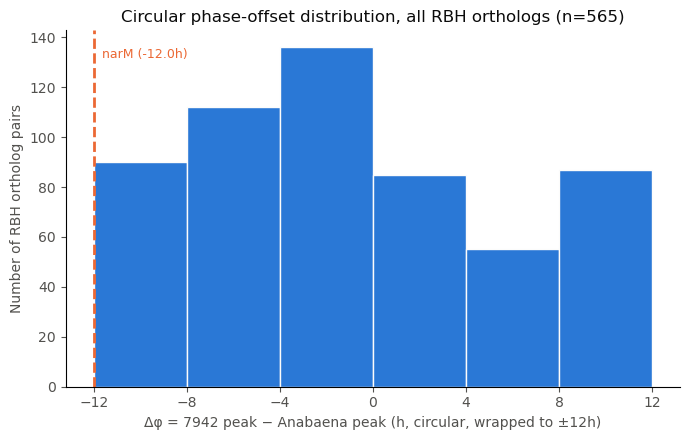

Saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/06_phase_offset_distribution.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

all_orthologs = pd.read_csv(processed_dir / "all_orthologs_rbh.csv")

def circular_diff_signed(a, b, period=24):
    # Wrap to (-period/2, period/2]. At exactly the antipode (|diff|==period/2) the sign
    # is arbitrary -- both directions are the same distance around the circle.
    return ((a - b + period / 2) % period) - period / 2

all_orthologs["delta_phi_h"] = circular_diff_signed(
    all_orthologs["peak_time_h_7942"], all_orthologs["peak_time_h_anabaena"]
)

n = len(all_orthologs)
print(f"n = {n} confirmed RBH ortholog pairs, both sides with expression data")

bins = np.arange(-12, 12.001, 4)  # 4h bins, matching the sampling resolution
narm_row = all_orthologs[all_orthologs["gene_symbol_7942"].str.lower() == "narm"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(all_orthologs["delta_phi_h"], bins=bins, color="#2a78d6", edgecolor="#fcfcfb", linewidth=1)
if not narm_row.empty:
    narm_dphi = narm_row["delta_phi_h"].iloc[0]
    ax.axvline(narm_dphi, color="#eb6834", linewidth=2, linestyle="--")
    ax.text(narm_dphi, ax.get_ylim()[1] * 0.95, f"  narM ({narm_dphi:+.1f}h)", color="#eb6834",
            fontsize=9, va="top", ha="left" if narm_dphi < 8 else "right")
ax.set_xlabel("Δφ = 7942 peak − Anabaena peak (h, circular, wrapped to ±12h)", color="#52514e")
ax.set_ylabel("Number of RBH ortholog pairs", color="#52514e")
ax.set_title(f"Circular phase-offset distribution, all RBH orthologs (n={n})", color="#0b0b0b")
ax.tick_params(colors="#52514e")
ax.set_xticks(bins)
sns.despine(ax=ax)
plt.tight_layout()

fig_path = repo_root / "figures" / "06_phase_offset_distribution.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved {fig_path}")


## 5. Shape of the distribution

Rayleigh test for non-uniformity (no astropy/pycircstat in this environment, implemented
directly -- standard formula, Zar's higher-order correction for the p-value). Separately,
a simple descriptive check for the dawn/dusk cluster-swap hypothesis: how much mass sits
near 0 (same-phase) vs. near the antipode ±12h (swapped-phase), vs. the uniform-noise
expectation of 1/6 per 4h bin. Kept descriptive, not a fitted mixture model -- the
question is which of (a) unimodal-near-0-with-outliers, (b) bimodal at 0 and ±12, or
(c) roughly uniform, the shape looks like.

In [7]:
angles = 2 * np.pi * all_orthologs["delta_phi_h"] / 24
C = np.sum(np.cos(angles))
S = np.sum(np.sin(angles))
R = np.sqrt(C**2 + S**2)
Rbar = R / n
Z = n * Rbar**2
# Zar (Biostatistical Analysis) higher-order correction to the asymptotic p ~ exp(-Z).
p_rayleigh = np.exp(-Z) * (
    1 + (2 * Z - Z**2) / (4 * n)
    - (24 * Z - 132 * Z**2 + 76 * Z**3 - 9 * Z**4) / (288 * n**2)
)
p_rayleigh = min(max(p_rayleigh, 0.0), 1.0)
mean_dphi = np.degrees(np.arctan2(S, C)) / 360 * 24  # back to hours

print(f"Rayleigh test for non-uniformity (n={n}):")
print(f"  mean resultant length R-bar = {Rbar:.4f}  (0 = uniform OR symmetric bimodal cancellation, 1 = all identical)")
print(f"  Z = {Z:.2f}, p = {p_rayleigh:.3e}")
print(f"  mean direction = {mean_dphi:+.2f}h (only meaningful if the distribution is actually unimodal)")

counts, edges = np.histogram(all_orthologs["delta_phi_h"], bins=bins)
uniform_count = n / 6
print(f"\nBin counts vs. uniform-noise expectation (n/6 = {uniform_count:.0f} per 4h bin):")
for lo, hi, c in zip(edges[:-1], edges[1:], counts):
    bar = "#" * int(c / max(counts) * 40)
    print(f"  [{lo:+5.0f}, {hi:+5.0f}) h: {c:4d}  ({c/n*100:4.1f}%)  {bar}")

near_zero_frac = counts[2:4].sum() / n  # the two central bins, [-4,4)
near_antipode_frac = (counts[0] + counts[-1]) / n  # the two edge bins, [-12,-8) + [8,12]
print(f"\nNear same-phase (|Δφ|<4h): {near_zero_frac*100:.1f}% of pairs (uniform expectation 33.3%)")
print(f"Near antipodal (|Δφ|>=8h): {near_antipode_frac*100:.1f}% of pairs (uniform expectation 33.3%)")


Rayleigh test for non-uniformity (n=565):
  mean resultant length R-bar = 0.1667  (0 = uniform OR symmetric bimodal cancellation, 1 = all identical)
  Z = 15.70, p = 1.373e-07
  mean direction = -4.55h (only meaningful if the distribution is actually unimodal)

Bin counts vs. uniform-noise expectation (n/6 = 94 per 4h bin):
  [  -12,    -8) h:   90  (15.9%)  ##########################
  [   -8,    -4) h:  112  (19.8%)  ################################
  [   -4,    +0) h:  136  (24.1%)  ########################################
  [   +0,    +4) h:   85  (15.0%)  #########################
  [   +4,    +8) h:   55  ( 9.7%)  ################
  [   +8,   +12) h:   87  (15.4%)  #########################

Near same-phase (|Δφ|<4h): 39.1% of pairs (uniform expectation 33.3%)
Near antipodal (|Δφ|>=8h): 31.3% of pairs (uniform expectation 33.3%)


## 6. Amplitude overlay — are the big offsets just low-amplitude noise?

A low-amplitude cosine has a poorly-localized peak (H3/H5 interaction): if a gene barely
oscillates on one side, its "peak time" there is close to arbitrary, so a large |Δφ| for
that pair could be measurement noise rather than a real phase shift. For each pair, take
the SMALLER of the two organisms' amplitudes (the weaker, more failure-prone side) and
flag the bottom quartile.

Spearman correlation, |Δφ| vs. weaker-side amplitude percentile: rho=+0.014, p=7.43e-01
(negative rho = low amplitude associates with larger |Δφ|, consistent with the noise hypothesis)

Bottom-quartile (weaker side) pairs: 197 / 565
Mean |Δφ|, bottom quartile:    5.61
Mean |Δφ|, rest:               5.81


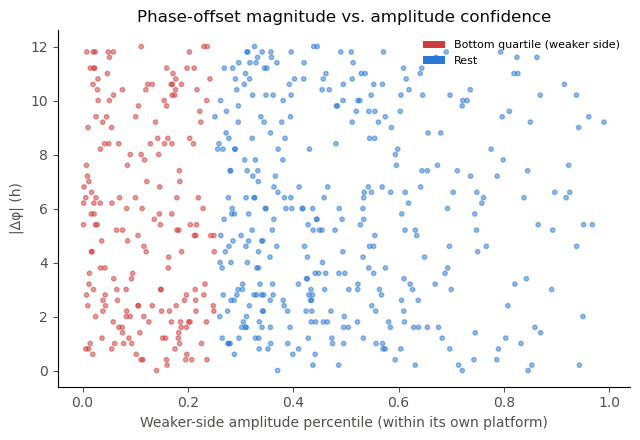

In [8]:
from scipy import stats as scipy_stats

# Raw CV isn't directly comparable across platforms (established earlier: Kushige's raw
# CVs run ~2.7x higher across the board than Ito's -- same H3 cross-platform issue). So
# rank each gene's amplitude WITHIN its own platform's full distribution first (not just
# the RBH subset), then take the worse (lower) percentile rank per pair as "the weaker
# side" -- comparable across platforms, unlike a raw min() of the two CVs would be.
ito_full["amp_pct_7942"] = ito_full["amplitude_cv_7942"].rank(pct=True)
kushige_full["amp_pct_anabaena"] = kushige_full["amplitude_cv_anabaena"].rank(pct=True)

all_orthologs = all_orthologs.merge(
    ito_full[["locus_tag_7942", "amp_pct_7942"]], on="locus_tag_7942", how="left"
).merge(
    kushige_full[["locus_tag_anabaena", "amp_pct_anabaena"]], on="locus_tag_anabaena", how="left"
)
all_orthologs["weaker_side_amp_pct"] = all_orthologs[["amp_pct_7942", "amp_pct_anabaena"]].min(axis=1)
all_orthologs["abs_delta_phi_h"] = all_orthologs["delta_phi_h"].abs()
all_orthologs["low_amp_quartile"] = all_orthologs["weaker_side_amp_pct"] <= 0.25

rho, pval = scipy_stats.spearmanr(all_orthologs["weaker_side_amp_pct"], all_orthologs["abs_delta_phi_h"])
print(f"Spearman correlation, |Δφ| vs. weaker-side amplitude percentile: rho={rho:+.3f}, p={pval:.2e}")
print("(negative rho = low amplitude associates with larger |Δφ|, consistent with the noise hypothesis)")

print(f"\nBottom-quartile (weaker side) pairs: {all_orthologs['low_amp_quartile'].sum()} / {n}")
print("Mean |Δφ|, bottom quartile:   ", all_orthologs.loc[all_orthologs["low_amp_quartile"], "abs_delta_phi_h"].mean().round(2))
print("Mean |Δφ|, rest:              ", all_orthologs.loc[~all_orthologs["low_amp_quartile"], "abs_delta_phi_h"].mean().round(2))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = np.where(all_orthologs["low_amp_quartile"], "#d03b3b", "#2a78d6")
ax.scatter(all_orthologs["weaker_side_amp_pct"], all_orthologs["abs_delta_phi_h"], c=colors, s=10, alpha=0.5)
ax.set_xlabel("Weaker-side amplitude percentile (within its own platform)", color="#52514e")
ax.set_ylabel("|Δφ| (h)", color="#52514e")
ax.set_title("Phase-offset magnitude vs. amplitude confidence", color="#0b0b0b")
ax.tick_params(colors="#52514e")
sns.despine(ax=ax)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#d03b3b", label="Bottom quartile (weaker side)"),
    Patch(facecolor="#2a78d6", label="Rest"),
], frameon=False, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## 7. Locate narM (and gap1 / kaiB, the two Version A name-matched survivors)

For each: Δφ, amplitude percentile rank on each side, and the actual peak times against
each organism's own modal peak (not just the offset) -- is this a special outlier, or an
instance of a general dawn/dusk-type swap that many genes undergo?

In [9]:
# Each organism's own modal peak region, from its FULL gene population (not just RBH
# orthologs) -- binned at 4h, same resolution as everything else here.
ito_peak_bins = pd.cut(ito_full["peak_time_h_7942"].dropna() % 24, bins=np.arange(0, 24.001, 4), right=False)
ito_modal_bin = ito_peak_bins.value_counts().idxmax()
kushige_peak_bins = pd.cut(kushige_full["peak_time_h_anabaena"].dropna() % 24, bins=np.arange(0, 24.001, 4), right=False)
kushige_modal_bin = kushige_peak_bins.value_counts().idxmax()
print(f"7942's own modal peak region (full 2515-gene population): {ito_modal_bin}")
print(f"Anabaena's own modal peak region (full 5336-gene population): {kushige_modal_bin}")

def locate_gene(symbol):
    row = all_orthologs[all_orthologs["gene_symbol_7942"].str.lower() == symbol.lower()]
    if row.empty:
        print(f"\n{symbol}: not in the RBH ortholog set (no reciprocal best hit, or no expression data on one side)")
        return
    row = row.iloc[0]
    print(f"\n{symbol} ({row['locus_tag_7942']} <-> {row['locus_tag_anabaena']}):")
    print(f"  Δφ = {row['delta_phi_h']:+.1f}h")
    print(f"  peak time: 7942={row['peak_time_h_7942']:.1f}h (organism's mode: {ito_modal_bin}),"
          f" Anabaena={row['peak_time_h_anabaena']:.1f}h (organism's mode: {kushige_modal_bin})")
    print(f"  amplitude percentile: 7942={row['amp_pct_7942']*100:.0f}th, Anabaena={row['amp_pct_anabaena']*100:.0f}th"
          f"  (weaker side: {row['weaker_side_amp_pct']*100:.0f}th{' -- BOTTOM QUARTILE' if row['low_amp_quartile'] else ''})")

for gene in ["narM", "gap1", "kaiB"]:
    locate_gene(gene)


7942's own modal peak region (full 2515-gene population): [20.0, 24.0)
Anabaena's own modal peak region (full 5336-gene population): [0.0, 4.0)

narM (Synpcc7942_0933 <-> alr0614):
  Δφ = -12.0h
  peak time: 7942=20.0h (organism's mode: [20.0, 24.0)), Anabaena=8.0h (organism's mode: [0.0, 4.0))
  amplitude percentile: 7942=44th, Anabaena=92th  (weaker side: 44th)

gap1 (Synpcc7942_0245 <-> all2566):
  Δφ = -5.4h
  peak time: 7942=10.6h (organism's mode: [20.0, 24.0)), Anabaena=16.0h (organism's mode: [0.0, 4.0))
  amplitude percentile: 7942=100th, Anabaena=87th  (weaker side: 87th)

kaiB (Synpcc7942_1217 <-> alr2885):
  Δφ = -8.8h
  peak time: 7942=11.2h (organism's mode: [20.0, 24.0)), Anabaena=20.0h (organism's mode: [0.0, 4.0))
  amplitude percentile: 7942=98th, Anabaena=27th  (weaker side: 27th)


## 8. Anabaena kaiB paralogs: canonical (operonic) vs. long-form (standalone)

Kushige2013's own data annotates TWO separate genes "kaiB" in Anabaena: `alr2885`,
sitting in the classic kaiABC operon (right next to `alr2884 kaiA` and `alr2886 kaiC`),
and `all3328`, standalone elsewhere in the genome. 7942 has no long-form KaiB paralog at
all (confirmed independently, not just absent from the RBH table), so this is an
Anabaena-internal comparison -- it was never going to show up in the RBH ortholog set
above since there's no reciprocal hit to find.

                  form locus_tag     protein_id  length_aa cycling_tier_Nplus  corr_p  amplitude_cv  peak_time_h
  canonical (operonic)   alr2885 WP_010997036.1        108                  b   0.046      0.275312           20
long-form (standalone)   all3328 WP_010997479.1        254                 AR     NaN      0.404461            0


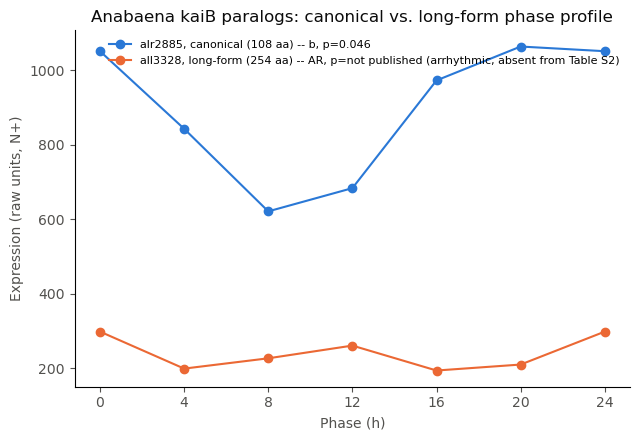


Contrary to a 'long form is the rhythmic one' hypothesis: the CANONICAL operonic
kaiB (alr2885, 108 aa) is the one Kushige calls cycling (p=0.046); the
long-form paralog (all3328, 254 aa) is arrhythmic by their own classification
(p=not published (arrhythmic, absent from Table S2)), despite a nominally higher raw CV (0.404 vs 0.275) --
a reminder (H3/H5 again) that CV alone without a significance test can mislead.


In [10]:
def protein_length(protein_id, faa_path):
    seq_len = 0
    capture = False
    with open(faa_path) as f:
        for line in f:
            if line.startswith(">"):
                capture = line[1:].split()[0] == protein_id
                continue
            if capture:
                seq_len += len(line.strip())
    return seq_len

anabaena_faa = genomes_dir / "anabaena_pcc7120_GCF_000009705.1" / "protein.faa"
kaib_tags = {"canonical (operonic)": "alr2885", "long-form (standalone)": "all3328"}

kaib_rows = []
for label, tag in kaib_tags.items():
    row = kushige_full[kushige_full["locus_tag_anabaena"] == tag].iloc[0]
    protein_id = kushige_map.loc[kushige_map["old_locus_tag"] == tag, "protein_id"].iloc[0]
    length_aa = protein_length(protein_id, anabaena_faa)
    kaib_rows.append({
        "form": label, "locus_tag": tag, "protein_id": protein_id, "length_aa": length_aa,
        "cycling_tier_Nplus": row["rhythmic_tier_anabaena"],
        "corr_p": row["corr_p_anabaena"], "amplitude_cv": row["amplitude_cv_anabaena"],
        "peak_time_h": row["peak_time_h_anabaena"],
    })
kaib_df = pd.DataFrame(kaib_rows)
print(kaib_df.to_string(index=False))

def fmt_p(p):
    # all3328 is arrhythmic (tier AR) and therefore absent from Table S2, the only
    # source of a real rhythmicity p-value -- say that explicitly (H11/D0) rather than
    # printing a bare "nan" that reads like a missing-data accident.
    return f"p={p:.3f}" if pd.notna(p) else "p=not published (arrhythmic, absent from Table S2)"

# N+ phase profile for both, same phase-fold method used throughout this notebook.
def phase_profile_nplus(locus_tag):
    row = kushige_raw[kushige_raw["ORF No."] == locus_tag].iloc[0]
    by_phase = {p: [] for p in phases}
    for t in ll_timepoints:
        p = t % 24
        by_phase[p].append(row[f"N+_1st_LL{t}"])
        by_phase[p].append(row[f"N+_2nd_LL{t}"])
    return {p: sum(v) / len(v) for p, v in by_phase.items()}

canonical_profile = phase_profile_nplus("alr2885")
long_profile = phase_profile_nplus("all3328")

plot_phases = phases + [24]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(plot_phases, [canonical_profile[p % 24] for p in plot_phases], marker="o", color="#2a78d6",
        label=f"alr2885, canonical (108 aa) -- {kaib_df.iloc[0]['cycling_tier_Nplus']}, {fmt_p(kaib_df.iloc[0]['corr_p'])}")
ax.plot(plot_phases, [long_profile[p % 24] for p in plot_phases], marker="o", color="#eb6834",
        label=f"all3328, long-form (254 aa) -- {kaib_df.iloc[1]['cycling_tier_Nplus']}, {fmt_p(kaib_df.iloc[1]['corr_p'])}")
ax.set_xticks(plot_phases)
ax.set_xlabel("Phase (h)", color="#52514e")
ax.set_ylabel("Expression (raw units, N+)", color="#52514e")
ax.set_title("Anabaena kaiB paralogs: canonical vs. long-form phase profile", color="#0b0b0b")
ax.tick_params(colors="#52514e")
sns.despine(ax=ax)
ax.legend(frameon=False, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nContrary to a 'long form is the rhythmic one' hypothesis: the CANONICAL operonic")
print(f"kaiB (alr2885, 108 aa) is the one Kushige calls cycling ({fmt_p(kaib_df.iloc[0]['corr_p'])}); the")
print(f"long-form paralog (all3328, 254 aa) is arrhythmic by their own classification")
print(f"({fmt_p(kaib_df.iloc[1]['corr_p'])}), despite a nominally higher raw CV ({kaib_df.iloc[1]['amplitude_cv']:.3f} vs {kaib_df.iloc[0]['amplitude_cv']:.3f}) --")
print(f"a reminder (H3/H5 again) that CV alone without a significance test can mislead.")


In [11]:
from pathlib import Path
import sys

def find_project_root(marker=".git"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}' above {p})")

# This cell intentionally keeps the save helper separate from the analysis cells.
# Run it only when you want to commit and push the notebook state.
# NOT executed automatically as part of a full-notebook run (D0, 2026-07-30) --
# committing/pushing is confirmed with the user separately, not triggered by re-running
# the analysis end to end.
# Redefines find_project_root() locally (rather than relying on cell 2 having run)
# since this cell is designed to be run standalone.

repo_path = find_project_root()
sys.path.insert(0, str(repo_path))
from git_workflow import save_and_push

current_nb = {
    "repo_path": str(repo_path),
    "message": "Update notebook",
    "files": ["VersionB_AllOrthologs.ipynb"],
    }

# save_and_push(config=current_nb)  # commented out -- run manually when ready to push